# Hermite Functions and the Quantum Harmonic Oscillator

## Hermite polynomials

The **Hermite polynomials** $H_n(x)$ satisfy the three-term recurrence:
$$
H_{n+1}(x) = 2x H_n(x) - 2n H_{n-1}(x), \quad H_0 = 1, \quad H_1 = 2x.
$$

## Hermite functions

The **Hermite functions** (or **Gauss–Hermite functions**) are:
$$
\psi_n(x) = \frac{1}{\sqrt{2^n n! \sqrt{\pi}}} H_n(x) e^{-x^2/2}.
$$
They form an **orthonormal basis** of $L^2(\mathbb{R})$: $\langle \psi_m, \psi_n \rangle = \delta_{mn}$.

## Eigenfunction of the Fourier transform

Hermite functions are **eigenfunctions of the Fourier transform**:
$$
\hat{\psi}_n(\omega) = (-i)^n \psi_n(\omega).
$$
This means they are perfectly localised in both time and frequency, achieving the Heisenberg uncertainty principle equality.

## Quantum harmonic oscillator

In quantum mechanics, $\psi_n$ are the energy eigenstates of the **harmonic oscillator** $H = -\frac{1}{2}\partial_{xx} + \frac{1}{2}x^2$:
$$
H\psi_n = \left(n + \frac{1}{2}\right) \psi_n.
$$
The energy levels are equally spaced with gap $\hbar\omega = 1$ (in natural units).

## Creation/annihilation operators

The **ladder operators** $a^+ = \frac{1}{\sqrt{2}}(x - \partial_x)$ and $a^- = \frac{1}{\sqrt{2}}(x + \partial_x)$ satisfy:
$$
a^+ \psi_n = \sqrt{n+1}\,\psi_{n+1}, \qquad a^- \psi_n = \sqrt{n}\,\psi_{n-1}.
$$

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, factorial
from ipywidgets import interact, IntSlider, FloatSlider

plt.rcParams['figure.dpi'] = 120

## Computing Hermite functions

We use the recurrence for numerical stability.

In [2]:
def hermite_functions(x, n_max):
    """Compute Hermite functions psi_0, ..., psi_{n_max} at points x."""
    N = len(x)
    psi = np.zeros((n_max+1, N))
    gauss = np.exp(-x**2/2)
    # psi_0
    psi[0] = np.pi**(-0.25) * gauss
    if n_max == 0: return psi
    # psi_1
    psi[1] = np.sqrt(2) * np.pi**(-0.25) * x * gauss
    # Recurrence: psi_{n+1} = sqrt(2/(n+1)) * x * psi_n - sqrt(n/(n+1)) * psi_{n-1}
    for n in range(1, n_max):
        psi[n+1] = (np.sqrt(2/(n+1)) * x * psi[n] -
                    np.sqrt(n/(n+1)) * psi[n-1])
    return psi

x = np.linspace(-6, 6, 800)
n_max = 8
Psi = hermite_functions(x, n_max)

# Verify orthonormality
print('Orthonormality check (should be I):')
G = np.trapz(Psi[:4, None, :] * Psi[None, :4, :], x, axis=2)
print(np.round(G, 3))

Orthonormality check (should be I):
[[ 1. -0. -0.  0.]
 [-0.  1. -0. -0.]
 [-0. -0.  1. -0.]
 [ 0. -0. -0.  1.]]


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_30768/3397923963.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  G = np.trapz(Psi[:4, None, :] * Psi[None, :4, :], x, axis=2)


## Visualising the first Hermite functions

We plot the first 9 Hermite functions along with the harmonic oscillator potential $V(x) = x^2/2$.

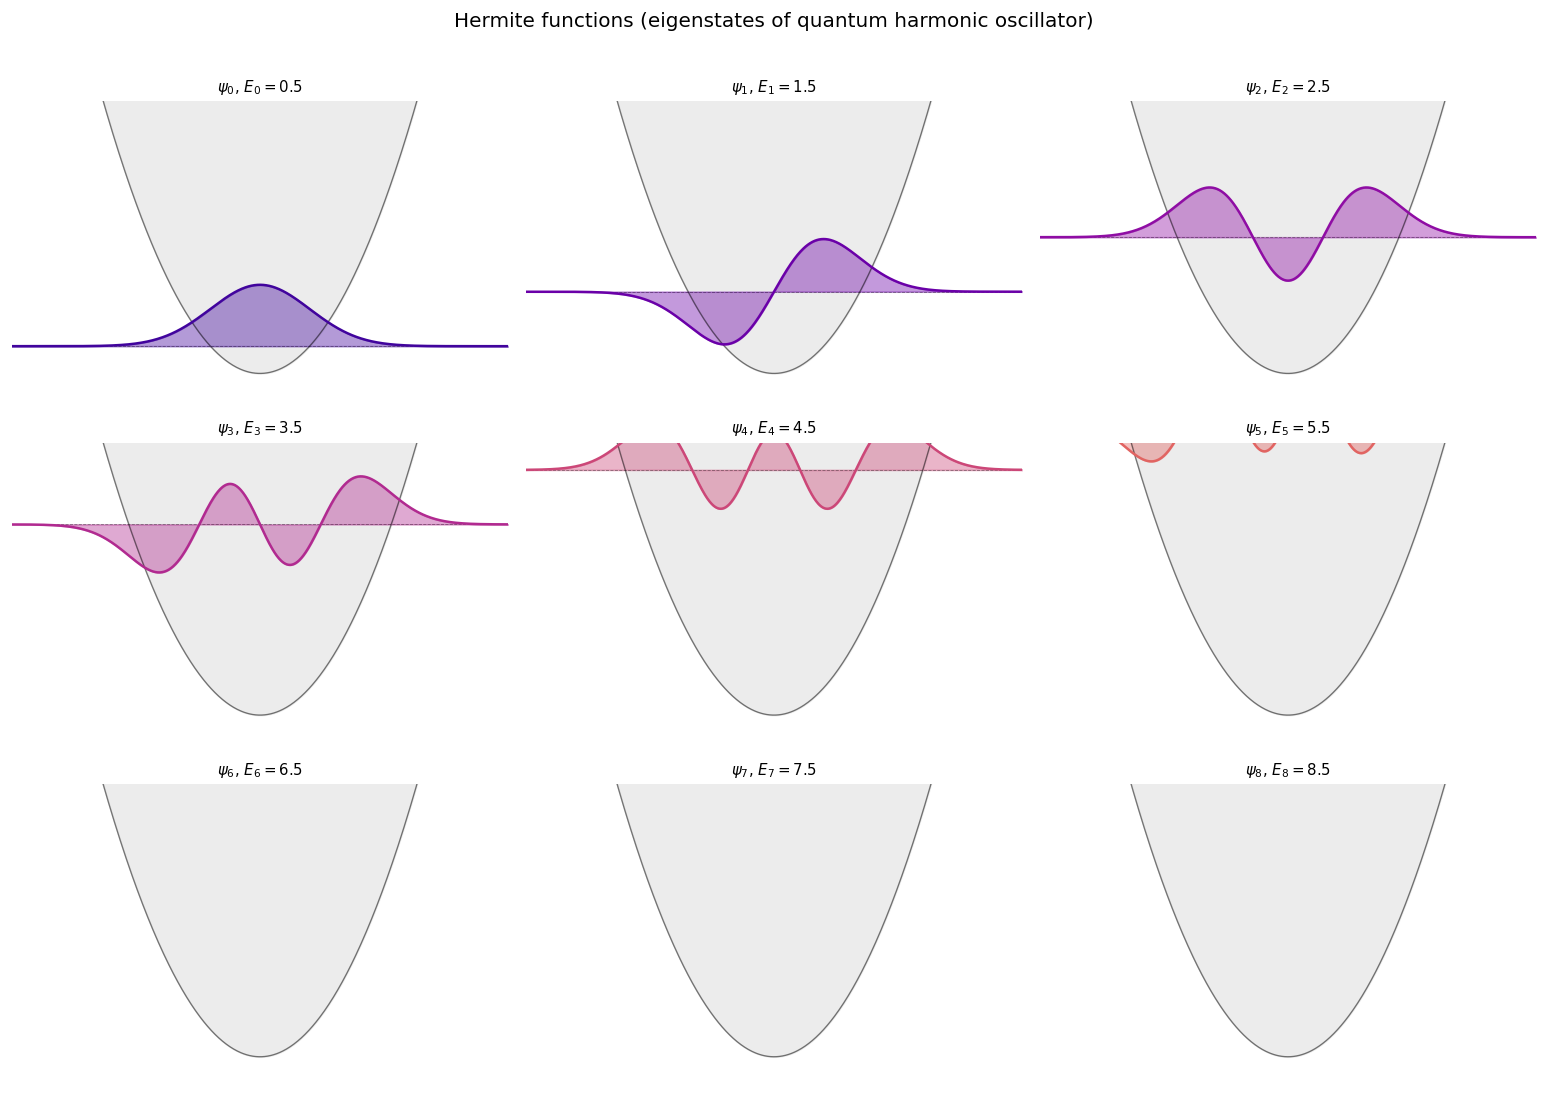

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
cols = plt.cm.plasma(np.linspace(0.1, 0.9, 9))

V = x**2 / 2  # potential

for n, (ax, col) in enumerate(zip(axes.ravel(), cols)):
    En = n + 0.5  # energy level
    ax.fill_between(x, V, 8, alpha=0.15, color='gray')
    ax.plot(x, V, 'k-', lw=0.8, alpha=0.5)
    ax.axhline(En, color='k', lw=0.5, ls='--', alpha=0.4)
    scale = 1.5
    ax.fill_between(x, En, En + scale*Psi[n], alpha=0.4, color=col)
    ax.plot(x, En + scale*Psi[n], color=col, lw=1.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-0.5, 5)
    ax.set_title(f'$\\psi_{{{n}}}$, $E_{{{n}}} = {En}$', fontsize=9)
    ax.axis('off')

fig.suptitle('Hermite functions (eigenstates of quantum harmonic oscillator)', y=1.01)
plt.tight_layout(); plt.show()

## Fourier eigenproperty

We verify that the Fourier transform of $\psi_n$ is $(-i)^n \psi_n$.

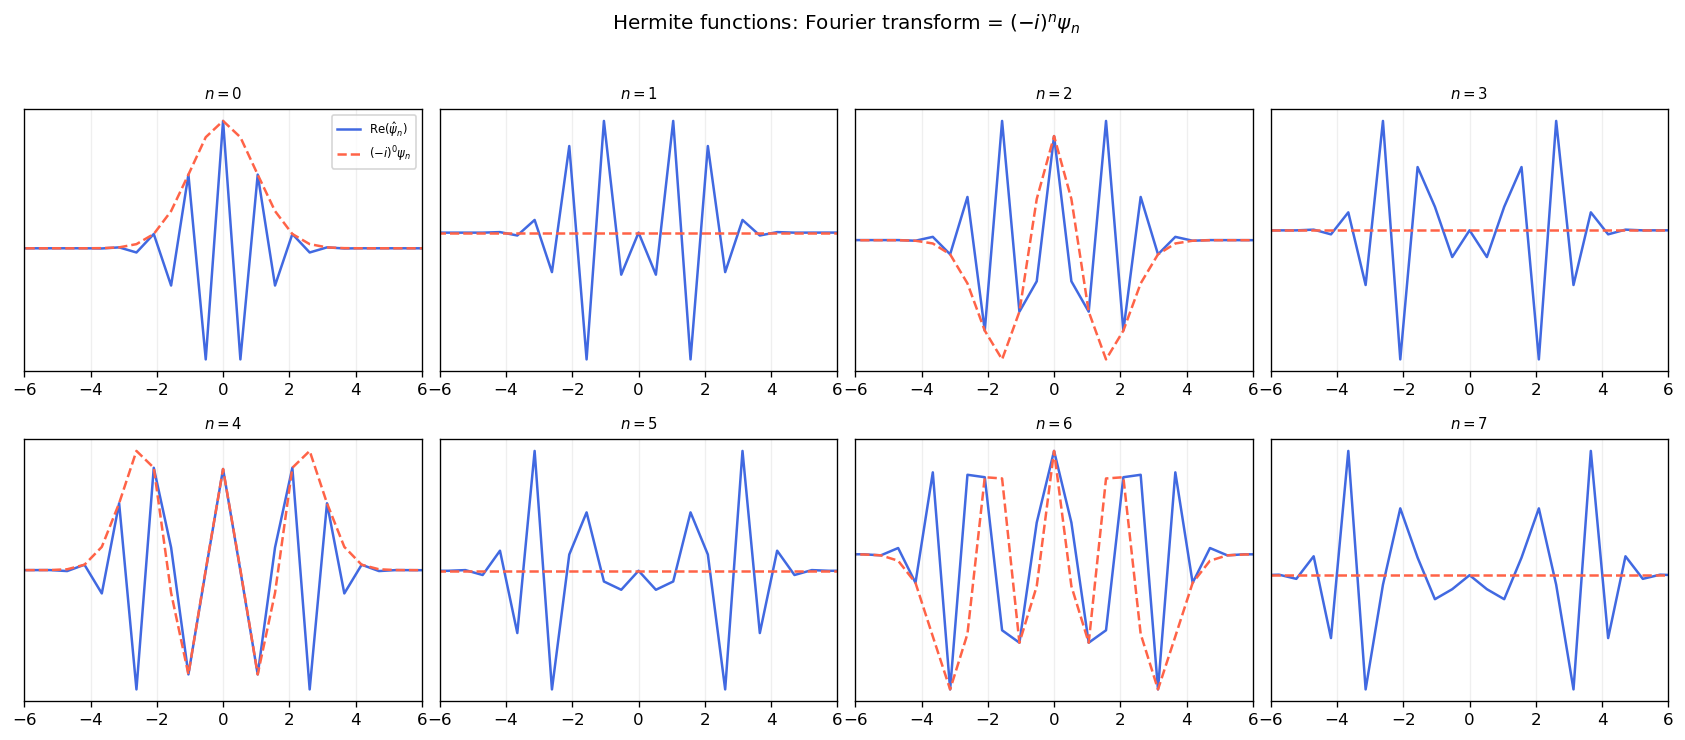

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for n, ax_row in enumerate(axes.ravel()[:8]):
    n_idx = n
    psi_n = Psi[n_idx]
    # Fourier transform (using FFT with proper normalisation)
    N = len(x)
    dx = x[1] - x[0]
    freqs = np.fft.fftshift(np.fft.fftfreq(N, d=dx/(2*np.pi)))
    psi_hat = np.fft.fftshift(np.fft.fft(psi_n)) * dx / np.sqrt(2*np.pi)
    # Expected: (-i)^n * psi_n evaluated at freqs
    # Interpolate psi_n to freq grid (close to x if 2pi normalised)
    omega = freqs  # angular frequency
    psi_at_omega = np.interp(omega, x, Psi[n_idx], left=0, right=0)
    expected = ((-1j)**n_idx) * psi_at_omega

    ax_row.plot(omega, psi_hat.real, 'royalblue', lw=1.5, label='$\\mathrm{Re}(\\hat{\\psi}_n)$')
    ax_row.plot(omega, expected.real, 'tomato', ls='--', lw=1.5, label=f'$(-i)^{n_idx}\\psi_n$')
    ax_row.set_xlim(-6, 6); ax_row.set_title(f'$n={n_idx}$', fontsize=9)
    ax_row.grid(alpha=0.2); ax_row.set_yticks([])
    if n == 0: ax_row.legend(fontsize=7)

fig.suptitle('Hermite functions: Fourier transform = $(-i)^n\\psi_n$', y=1.02)
plt.tight_layout(); plt.show()

## Wigner distribution

The **Wigner function** $W_n(x,\omega)$ is the time-frequency representation of $\psi_n$. For $\psi_0$ (Gaussian), it is a Gaussian in phase space; for higher $n$, it shows quantum oscillations.

/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_30768/185662064.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  W[i, j] = np.trapz(integrand.real, tau) / (2*np.pi)


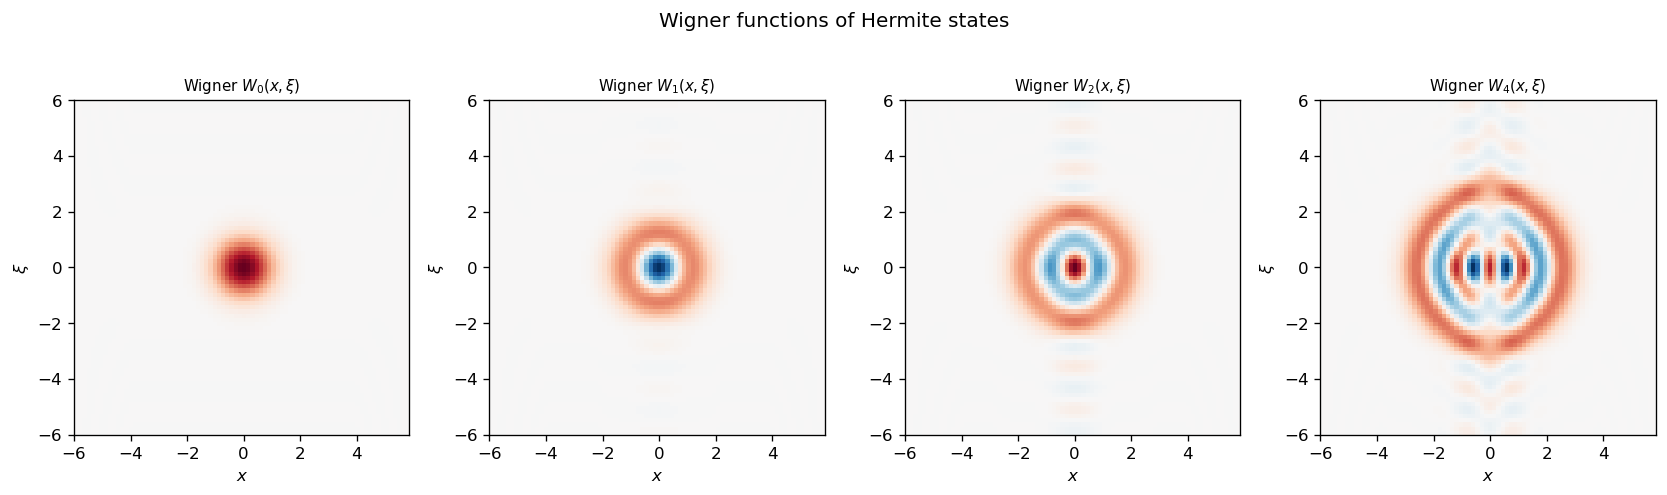

In [5]:
def wigner(psi, x_vals, n_pts=80):
    """Compute Wigner function W(x, xi) via the definition."""
    xi_vals = np.linspace(-6, 6, n_pts)
    W = np.zeros((n_pts, n_pts))
    for i, xi in enumerate(xi_vals):
        for j, xv in enumerate(x_vals[::x_vals.size//n_pts]):
            tau = np.linspace(-4, 4, 200)
            psi_plus  = np.interp(xv + tau/2, x_vals, psi, left=0, right=0)
            psi_minus = np.interp(xv - tau/2, x_vals, np.conj(psi), left=0, right=0)
            integrand = psi_plus * psi_minus * np.exp(1j * xi * tau)
            W[i, j] = np.trapz(integrand.real, tau) / (2*np.pi)
    return W, xi_vals, x_vals[::x_vals.size//n_pts]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for n_w, ax in zip([0, 1, 2, 4], axes):
    W, xi_v, x_v = wigner(Psi[n_w], x)
    vmax = np.abs(W).max()
    ax.imshow(W, extent=[x_v[0], x_v[-1], xi_v[0], xi_v[-1]],
              cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto', origin='lower')
    ax.set_xlabel('$x$'); ax.set_ylabel('$\\xi$')
    ax.set_title(f'Wigner $W_{{{n_w}}}(x,\\xi)$', fontsize=9)

fig.suptitle('Wigner functions of Hermite states', y=1.02)
plt.tight_layout(); plt.show()

## Interactive: Hermite function and uncertainty

In [6]:
def show_hermite(n=0):
    psi_n = Psi[n]
    dx_v = x[1] - x[0]
    # Position uncertainty
    x2 = np.trapz(x**2 * psi_n**2, x)
    x_mean = np.trapz(x * psi_n**2, x)
    sigma_x = np.sqrt(x2 - x_mean**2)
    # Momentum uncertainty (via gradient)
    dpsi = np.gradient(psi_n, x)
    sigma_p = np.sqrt(np.trapz(dpsi**2, x))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(x, psi_n, 'royalblue', lw=2)
    axes[0].fill_between(x, psi_n, alpha=0.3, color='royalblue')
    axes[0].plot(x, x**2/2 / (n+1) * max(abs(psi_n)), 'k--', lw=0.8, alpha=0.4)
    axes[0].set_xlim(-6, 6); axes[0].set_xlabel('$x$')
    axes[0].set_title(f'$\\psi_{{{n}}}(x)$')
    axes[0].grid(alpha=0.3)
    # Fourier transform
    N2 = len(x)
    freqs2 = np.fft.fftshift(np.fft.fftfreq(N2, d=dx_v/(2*np.pi)))
    phat = np.abs(np.fft.fftshift(np.fft.fft(psi_n))) * dx_v / np.sqrt(2*np.pi)
    axes[1].plot(freqs2, phat, 'tomato', lw=2)
    axes[1].set_xlim(-6, 6); axes[1].set_xlabel('$\\omega$')
    axes[1].set_title(fr'$|\hat{{\psi}}_{{{n}}}(\omega)|$   |   $\sigma_x={sigma_x:.3f}$, $\sigma_p={sigma_p:.3f}$, $\sigma_x\sigma_p={sigma_x*sigma_p:.3f}$')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_hermite,
         n=IntSlider(value=0, min=0, max=8, step=1, description='$n$'));

interactive(children=(IntSlider(value=0, description='$n$', max=8), Output()), _dom_classes=('widget-interact'…

## Bibliographical resources

- Hermite, C. (1864). Sur un nouveau développement en série de fonctions. *Comptes Rendus de l'Académie des Sciences*, 58, 93–100.
- Szegő, G. (1939). *Orthogonal Polynomials*. American Mathematical Society.
- Griffiths, D. J. (2005). *Introduction to Quantum Mechanics* (2nd ed.). Pearson.
- Folland, G. B. (1989). *Harmonic Analysis in Phase Space*. Princeton University Press.
- Abramowitz, M. and Stegun, I. A. (1972). *Handbook of Mathematical Functions*. Dover. Chapter 22.